In [12]:
import pandas as pd
df = pd.read_json("data/News_Category_Dataset_v3.json", lines=True)
df = df[['category', 'short_description']]  # Use short_description or headline
print(df.head())
print(df['category'].value_counts())


    category                                  short_description
0  U.S. NEWS  Health experts said it is too early to predict...
1  U.S. NEWS  He was subdued by passengers and crew when he ...
2     COMEDY  "Until you have a dog you don't understand wha...
3  PARENTING  "Accidentally put grown-up toothpaste on my to...
4  U.S. NEWS  Amy Cooper accused investment firm Franklin Te...
category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3572
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPO

In [13]:
broad_cats = {
    'POLITICS': 'POLITICS',
    'WORLD NEWS': 'GEOPOLITICS',
    'WELLNESS': 'HEALTH',
    'ENTERTAINMENT': 'ENTERTAINMENT',
    'PARENTING': 'EDUCATION',
    'TECH': 'TECHNOLOGY',
    'SCIENCE': 'SCIENCE',
    'BUSINESS': 'BUSINESS/FINANCE',
    'SPORTS': 'SPORTS',
    'STYLE & BEAUTY': 'LIFESTYLE',
    'GREEN': 'ENVIRONMENT'
}
df = df[df['category'].isin(broad_cats)]

In [20]:
df['mapped_category'] = df['category'].map(broad_cats)
df = df.dropna(subset=['mapped_category'])  # Remove rows not in your target set

In [14]:
df.drop_duplicates(subset='short_description', inplace=True)
df.dropna(subset=['short_description', 'category'], inplace=True)

In [15]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)  # remove URLs
    text = re.sub(r"[^a-z\s]", "", text)  # remove punctuation/numbers
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['clean_text'] = df['short_description'].apply(clean_text)

In [16]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in stop_words])

df['clean_text'] = df['clean_text'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\megha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [21]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['label_encoded'] = encoder.fit_transform(df['mapped_category'])

In [22]:
print(df['mapped_category'].value_counts())

mapped_category
POLITICS            32020
HEALTH              17668
ENTERTAINMENT       14626
LIFESTYLE            9314
EDUCATION            8737
BUSINESS/FINANCE     5115
SPORTS               4369
GEOPOLITICS          3291
ENVIRONMENT          2036
TECHNOLOGY           2012
SCIENCE              1796
Name: count, dtype: int64


In [5]:
import pandas as pd
import re
import joblib
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from sklearn.calibration import CalibratedClassifierCV
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Load and map categories
df = pd.read_json("data/News_Category_Dataset_v3.json", lines=True)
category_map = {
    'POLITICS': 'POLITICS',
    'WORLD NEWS': 'GEOPOLITICS',
    'WELLNESS': 'HEALTH',
    'ENTERTAINMENT': 'ENTERTAINMENT',
    'PARENTING': 'EDUCATION',
    'TECH': 'TECHNOLOGY',
    'SCIENCE': 'SCIENCE',
    'BUSINESS': 'BUSINESS/FINANCE',
    'SPORTS': 'SPORTS',
    'STYLE & BEAUTY': 'LIFESTYLE',
    'GREEN': 'ENVIRONMENT'
}
df['mapped_category'] = df['category'].map(category_map)
df.dropna(subset=['mapped_category'], inplace=True)

# Combine headline and short_description for richer context
df['full_text'] = df['headline'] + " " + df['short_description']

# Clean text
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return " ".join([word for word in text.split() if word not in stop_words])

df['clean_text'] = df['full_text'].apply(clean_text)

# Encode labels
encoder = LabelEncoder()
df['label_encoded'] = encoder.fit_transform(df['mapped_category'])

# TF-IDF with bigrams and more features
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1,2),
    min_df=3
)
X = vectorizer.fit_transform(df['clean_text'])
y = df['label_encoded']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Train model

base_model = LinearSVC(class_weight='balanced', max_iter=2000)
model = CalibratedClassifierCV(base_model, cv=3)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=encoder.classes_))
print("Accuracy:", accuracy_score(y_test, y_pred))

# Save
joblib.dump(model, "category_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
joblib.dump(encoder, "label_encoder.pkl")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\megha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                  precision    recall  f1-score   support

BUSINESS/FINANCE       0.64      0.50      0.56      1198
       EDUCATION       0.76      0.72      0.74      1758
   ENTERTAINMENT       0.78      0.82      0.80      3473
     ENVIRONMENT       0.60      0.39      0.47       524
     GEOPOLITICS       0.65      0.45      0.54       660
          HEALTH       0.76      0.86      0.81      3589
       LIFESTYLE       0.87      0.83      0.85      1963
        POLITICS       0.83      0.90      0.87      7121
         SCIENCE       0.70      0.41      0.52       441
          SPORTS       0.75      0.67      0.71      1015
      TECHNOLOGY       0.67      0.40      0.50       421

        accuracy                           0.79     22163
       macro avg       0.73      0.63      0.67     22163
    weighted avg       0.78      0.79      0.78     22163

Accuracy: 0.7852727518837702


['label_encoder.pkl']

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\megha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



🔍 Evaluating Logistic Regression
                  precision    recall  f1-score   support

BUSINESS/FINANCE       0.50      0.55      0.52       116
       EDUCATION       0.71      0.70      0.71       155
   ENTERTAINMENT       0.76      0.77      0.76       307
     ENVIRONMENT       0.28      0.41      0.33        49
     GEOPOLITICS       0.46      0.60      0.52        60
          HEALTH       0.72      0.79      0.75       324
       LIFESTYLE       0.87      0.79      0.83       168
        POLITICS       0.90      0.75      0.82       652
         SCIENCE       0.37      0.60      0.46        40
          SPORTS       0.68      0.69      0.69        91
      TECHNOLOGY       0.37      0.53      0.43        38

        accuracy                           0.72      2000
       macro avg       0.60      0.65      0.62      2000
    weighted avg       0.75      0.72      0.73      2000

Accuracy: 0.723


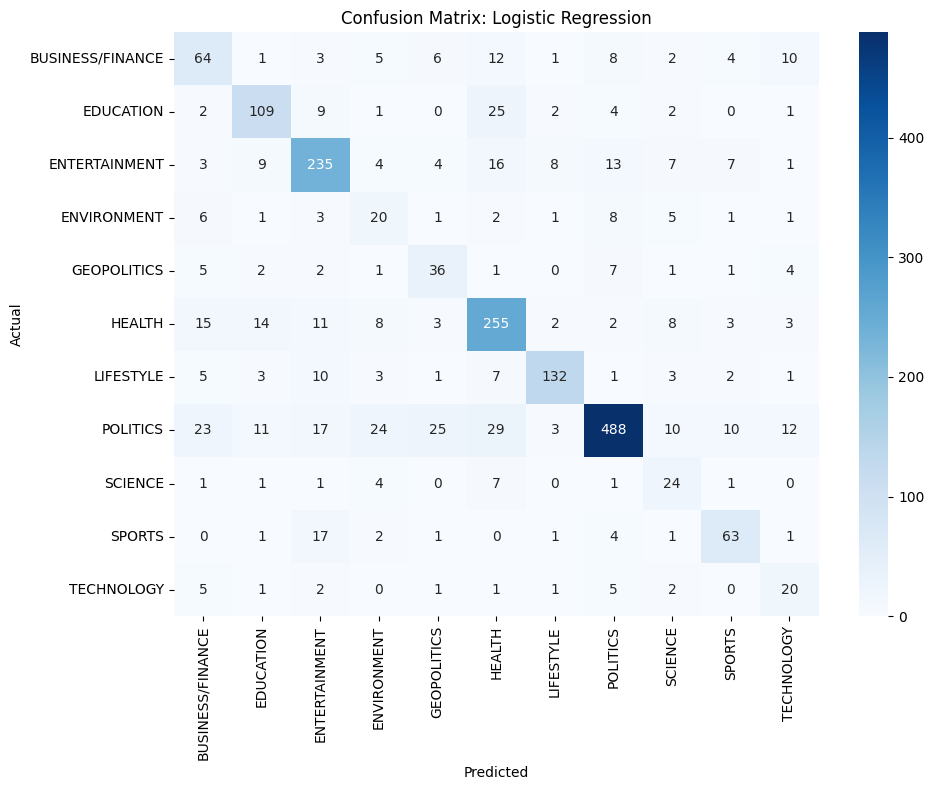


🔍 Evaluating Random Forest
                  precision    recall  f1-score   support

BUSINESS/FINANCE       0.66      0.35      0.46       116
       EDUCATION       0.66      0.68      0.67       155
   ENTERTAINMENT       0.64      0.62      0.63       307
     ENVIRONMENT       0.36      0.24      0.29        49
     GEOPOLITICS       0.54      0.22      0.31        60
          HEALTH       0.64      0.79      0.71       324
       LIFESTYLE       0.83      0.76      0.80       168
        POLITICS       0.72      0.86      0.79       652
         SCIENCE       0.50      0.23      0.31        40
          SPORTS       0.75      0.45      0.56        91
      TECHNOLOGY       0.59      0.34      0.43        38

        accuracy                           0.68      2000
       macro avg       0.63      0.50      0.54      2000
    weighted avg       0.68      0.68      0.67      2000

Accuracy: 0.6845


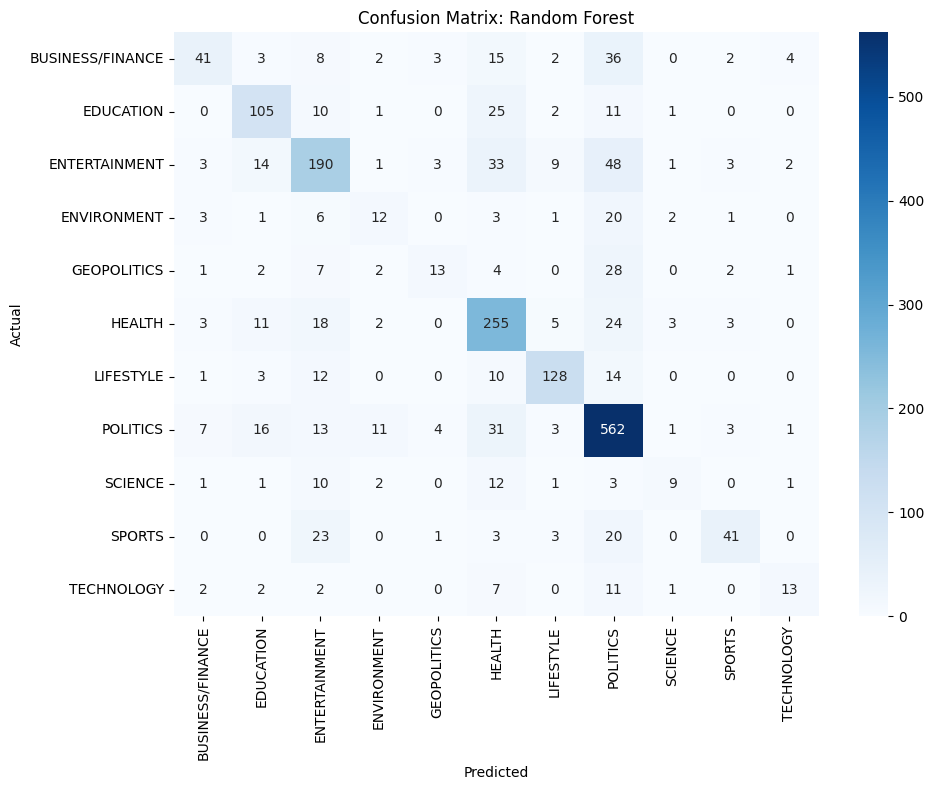


🔍 Evaluating XGBoost


d:\AIML_PROJECT\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:51:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


                  precision    recall  f1-score   support

BUSINESS/FINANCE       0.66      0.38      0.48       116
       EDUCATION       0.71      0.59      0.65       155
   ENTERTAINMENT       0.67      0.69      0.68       307
     ENVIRONMENT       0.36      0.27      0.31        49
     GEOPOLITICS       0.48      0.20      0.28        60
          HEALTH       0.69      0.81      0.75       324
       LIFESTYLE       0.83      0.76      0.80       168
        POLITICS       0.71      0.87      0.78       652
         SCIENCE       0.47      0.23      0.31        40
          SPORTS       0.72      0.47      0.57        91
      TECHNOLOGY       0.62      0.34      0.44        38

        accuracy                           0.70      2000
       macro avg       0.63      0.51      0.55      2000
    weighted avg       0.69      0.70      0.68      2000

Accuracy: 0.697


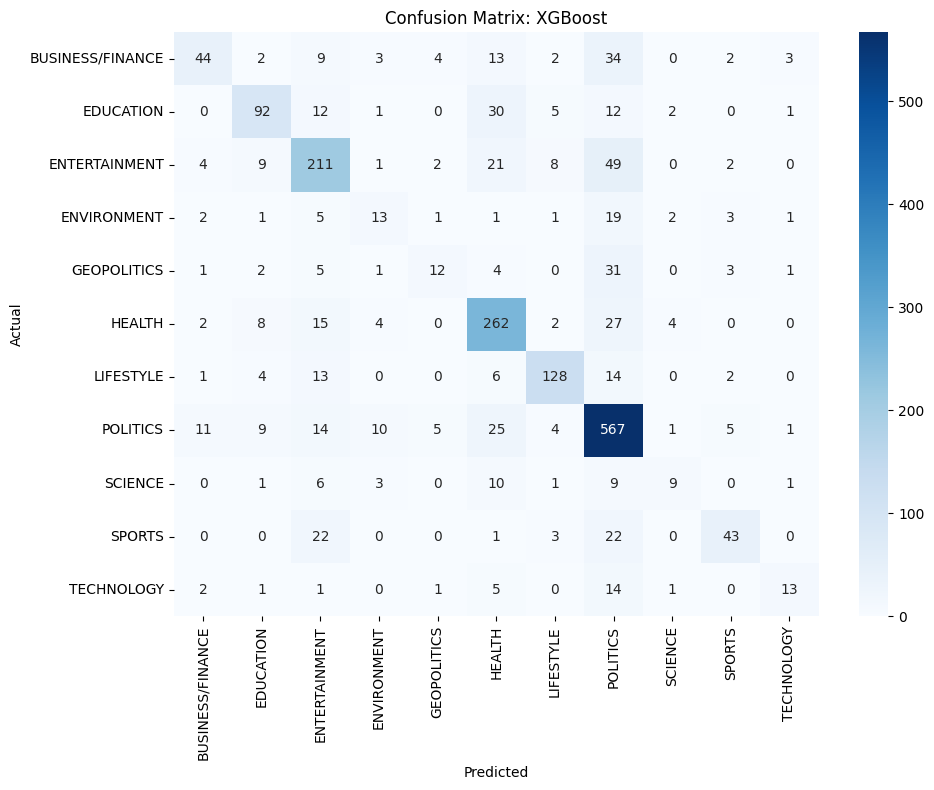

In [ ]:
"""
import pandas as pd
import re
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Load and map categories
df = pd.read_json("data/News_Category_Dataset_v3.json", lines=True)
category_map = {
    'POLITICS': 'POLITICS',
    'WORLD NEWS': 'GEOPOLITICS',
    'WELLNESS': 'HEALTH',
    'ENTERTAINMENT': 'ENTERTAINMENT',
    'PARENTING': 'EDUCATION',
    'TECH': 'TECHNOLOGY',
    'SCIENCE': 'SCIENCE',
    'BUSINESS': 'BUSINESS/FINANCE',
    'SPORTS': 'SPORTS',
    'STYLE & BEAUTY': 'LIFESTYLE',
    'GREEN': 'ENVIRONMENT'
}
df['mapped_category'] = df['category'].map(category_map)
df.dropna(subset=['mapped_category'], inplace=True)

df = df.sample(n=10000, random_state=42)
# Combine headline and short_description
df['full_text'] = df['headline'] + " " + df['short_description']

# Clean text
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return " ".join([word for word in text.split() if word not in stop_words])

df['clean_text'] = df['full_text'].apply(clean_text)

# Encode labels
encoder = LabelEncoder()
df['label_encoded'] = encoder.fit_transform(df['mapped_category'])

# TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1,2), min_df=3)
X = vectorizer.fit_transform(df['clean_text'])
y = df['label_encoded']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100,class_weight='balanced'),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

# Train, evaluate, and plot confusion matrix
for name, model in models.items():
    print(f"\n🔍 Evaluating {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(classification_report(y_test, y_pred, target_names=encoder.classes_))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=encoder.classes_, yticklabels=encoder.classes_, cmap='Blues')
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

# Save best model manually if needed
# joblib.dump(models["XGBoost"], "category_model_xgb.pkl")
"""

Fitting 3 folds for each of 9 candidates, totalling 27 fits

🔍 Best Parameters: {'C': 0.1, 'max_iter': 1000}

✅ Training completed in 62.30 seconds
✅ Accuracy: 0.7885

Classification Report:
                  precision    recall  f1-score   support

BUSINESS/FINANCE       0.66      0.52      0.58      1198
       EDUCATION       0.77      0.72      0.75      1758
   ENTERTAINMENT       0.77      0.82      0.79      3473
     ENVIRONMENT       0.59      0.45      0.51       524
     GEOPOLITICS       0.66      0.49      0.56       660
          HEALTH       0.76      0.87      0.81      3589
       LIFESTYLE       0.86      0.82      0.84      1963
        POLITICS       0.84      0.90      0.87      7121
         SCIENCE       0.72      0.45      0.56       441
          SPORTS       0.77      0.68      0.73      1015
      TECHNOLOGY       0.69      0.46      0.55       421

        accuracy                           0.79     22163
       macro avg       0.74      0.65      0.69     2

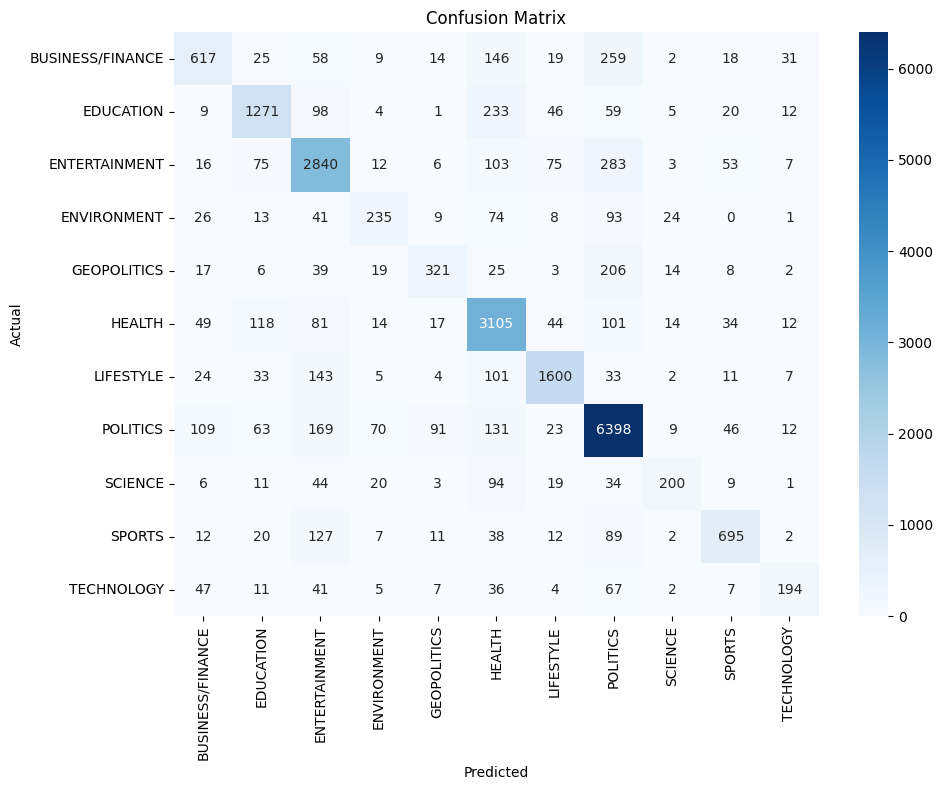

['label_encoder.pkl']

In [ ]:
"""
import pandas as pd
import re
import joblib
import time
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
import nltk

# Only download if not already present
try:
    stop_words = set(stopwords.words('english'))
except LookupError:
    nltk.download('stopwords')
    stop_words = set(stopwords.words('english'))
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return " ".join([word for word in text.split() if word not in stop_words])

# Load and preprocess
df_huffpost = pd.read_json("data/News_Category_Dataset_v3.json", lines=True)
df_tech = pd.read_json("data/tech_articles.jsonl", lines=True)
df_combined = pd.concat([df_huffpost, df_tech], ignore_index=True)
df_combined.to_json("data/combined_dataset.json", orient="records", lines=True)
category_map = {
    'POLITICS': 'POLITICS',
    'WORLD NEWS': 'GEOPOLITICS',
    'WELLNESS': 'HEALTH',
    'ENTERTAINMENT': 'ENTERTAINMENT',
    'PARENTING': 'EDUCATION',
    'TECH': 'TECHNOLOGY',
    'SCIENCE': 'SCIENCE',
    'BUSINESS': 'BUSINESS/FINANCE',
    'SPORTS': 'SPORTS',
    'STYLE & BEAUTY': 'LIFESTYLE',
    'GREEN': 'ENVIRONMENT'
}
df['mapped_category'] = df['category'].map(category_map)
df.dropna(subset=['mapped_category'], inplace=True)

# Optional: subsample for faster iteration
# df = df.sample(n=10000, random_state=42)

df['full_text'] = df['headline'] + " " + df['short_description']
df['clean_text'] = df['full_text'].apply(clean_text)

# Encode labels
encoder = LabelEncoder()
df['label_encoded'] = encoder.fit_transform(df['mapped_category'])

# TF-IDF
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1,2),
    min_df=3
)
X_tfidf = vectorizer.fit_transform(df['clean_text'])
y = df['label_encoded']

# Apply TruncatedSVD
from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(n_components=300, random_state=42)
X_reduced = svd.fit_transform(X_tfidf)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, stratify=y, test_size=0.2, random_state=42)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# GridSearch for LinearSVC
start_time = time.time()
param_grid = {
    'C': [0.1, 1, 10],
    'max_iter': [1000, 2000, 5000]
}
grid = GridSearchCV(LinearSVC(class_weight='balanced'), param_grid, cv=3, scoring='accuracy', verbose=1, n_jobs=-1)
grid.fit(X_train, y_train)
best_svc = grid.best_estimator_
print(f"\n🔍 Best Parameters: {grid.best_params_}")

# Calibrate for probabilities
model = CalibratedClassifierCV(best_svc, cv=3)
model.fit(X_train, y_train)
train_time = time.time() - start_time

# Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Training completed in {train_time:.2f} seconds")
print(f"✅ Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=encoder.classes_, yticklabels=encoder.classes_, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Save artifacts
timestamp = time.strftime("%Y%m%d-%H%M%S")
joblib.dump(model, f"category_model.pkl")
joblib.dump(vectorizer, f"tfidf_vectorizer.pkl")
joblib.dump(encoder, f"label_encoder.pkl")
"""

In [ ]:
import pandas as pd
import re
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments

# Load and preprocess
df_huffpost = pd.read_json("data/News_Category_Dataset_v3.json", lines=True)
df_tech = pd.read_json("data/tech_articles.jsonl", lines=True)
df_combined = pd.concat([df_huffpost, df_tech], ignore_index=True)

category_map = {
    'POLITICS': 'POLITICS',
    'WORLD NEWS': 'GEOPOLITICS',
    'WELLNESS': 'HEALTH',
    'ENTERTAINMENT': 'ENTERTAINMENT',
    'PARENTING': 'EDUCATION',
    'TECH': 'TECHNOLOGY',
    'SCIENCE': 'SCIENCE',
    'BUSINESS': 'BUSINESS/FINANCE',
    'SPORTS': 'SPORTS',
    'STYLE & BEAUTY': 'LIFESTYLE',
    'GREEN': 'ENVIRONMENT'
}

df_combined['mapped_category'] = df_combined['category'].map(category_map)
df_combined.dropna(subset=["headline", "short_description", "mapped_category"], inplace=True)
df_combined["full_text"] = df_combined["headline"] + " " + df_combined["short_description"]

# Encode labels
encoder = LabelEncoder()
labels_encoded = encoder.fit_transform(df_combined["mapped_category"])

# Train/test split
texts_train, texts_test, labels_train, labels_test = train_test_split(
    df_combined["full_text"].tolist(),
    labels_encoded,
    test_size=0.2,
    stratify=labels_encoded,
    random_state=42
)

# Tokenize
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
train_encodings = tokenizer(texts_train, truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(texts_test, truncation=True, padding=True, max_length=128)

# Dataset class
class NewsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_dataset = NewsDataset(train_encodings, labels_train)
test_dataset = NewsDataset(test_encodings, labels_test)

# Load model
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=len(encoder.classes_))

# Training setup
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    logging_dir="./logs"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

# Train
trainer.train()

# Predict
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_test = labels_test

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

In [ ]:
import requests
from bs4 import BeautifulSoup

url = "https://www.theverge.com/2025/11/15/ai-transcription-whatsapp"
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

title_tag = soup.find('title')
headline = title_tag.text.strip() if title_tag else "No title found"

description_tag = soup.find('meta', attrs={'name': 'description'})
description = description_tag['content'].strip() if description_tag and 'content' in description_tag.attrs else "No description found"

tech_data = [{
    "headline": headline,
    "short_description": description,
    "category": "TECH"
}]

In [ ]:
import requests
from bs4 import BeautifulSoup

url = "https://www.theverge.com/2025/11/15/ai-transcription-whatsapp"
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

title_tag = soup.find('title')
headline = title_tag.text.strip() if title_tag else "No title found"

description_tag = soup.find('meta', attrs={'name': 'description'})
description = description_tag['content'].strip() if description_tag and 'content' in description_tag.attrs else "No description found"

tech_data = [{
    "headline": headline,
    "short_description": description,
    "category": "TECH"
}]

In [25]:
import json

with open("data/tech_articles.jsonl", "a") as f:
    for item in tech_data:
        f.write(json.dumps(item) + "\n")
        

In [ ]:
import pandas as pd

df = pd.read_excel("data/bias_dataset.xlsx")
print(df.columns)

d:\AIML_PROJECT\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Index(['Unnamed: 0', 'sentence', 'news_link', 'outlet', 'topic', 'type',
       'group_id', 'num_sent', 'Label_bias', 'Label_opinion', 'article',
       'biased_words4'],
      dtype='object')


In [74]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\megha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [75]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
print("Stopwords loaded:", len(stop_words))

Stopwords loaded: 198


In [67]:
df["bias_label"] = df["Label_bias"] 
print(df["bias_label"].value_counts())

bias_label
Biased          1018
Non-biased       533
No agreement     149
Name: count, dtype: int64


In [68]:
df_filtered = df[df["bias_label"] != "No agreement"]

In [69]:
df["full_text"] = df["sentence"].fillna("") + " " + df["article"].fillna("")

def clean_text(text):
    import re
    from nltk.corpus import stopwords
    stop_words = set(stopwords.words("english"))
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return " ".join([word for word in text.split() if word not in stop_words])

df["clean_text"] = df["full_text"].apply(clean_text)

In [71]:
from sklearn.model_selection import train_test_split

X = df_filtered["clean_text"]
y = df_filtered["bias_label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [72]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, stop_words="english")),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=2000))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Biased       0.83      0.78      0.80       204
  Non-biased       0.62      0.69      0.65       107

    accuracy                           0.75       311
   macro avg       0.72      0.74      0.73       311
weighted avg       0.76      0.75      0.75       311



In [73]:
import joblib
joblib.dump(pipeline, "bias_model.pkl")

['bias_model.pkl']

In [97]:
import pandas as pd

# Load all splits
train_df = pd.read_csv("data/train.tsv", sep="\t", header=None)
test_df = pd.read_csv("data/test.tsv", sep="\t", header=None)
valid_df = pd.read_csv("data/valid.tsv", sep="\t", header=None)

# Combine and rename columns
df = pd.concat([train_df, test_df, valid_df], ignore_index=True)
df.columns = [
    "statement_id", "truth_label", "statement_text", "statement_subject", "speaker_name",
    "speaker_job", "speaker_state", "speaker_party", "count_barely_true", "count_false",
    "count_half_true", "count_mostly_true", "count_pants_on_fire"," "
]

In [107]:
def simplify_factuality(label):
    label = label.lower()
    if label in ["true", "mostly-true"]:
        return "factual"
    elif label in ["false", "pants-fire"]:
        return "non-factual"
    else:
        return "mixed"

df["factuality_label"] = df["truth_label"].apply(simplify_factuality)

In [108]:
import re
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|[^a-z\s]", "", text)
    return " ".join([word for word in text.split() if word not in stop_words])

df["clean_text"] = df["statement_text"].apply(clean_text)

In [109]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df["factuality_encoded"] = encoder.fit_transform(df["factuality_label"])

In [110]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
X = vectorizer.fit_transform(df["clean_text"])
y = df["factuality_encoded"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = SVC(probability=True, class_weight="balanced")
model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [111]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.4342


In [112]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

[[437 252 185]
 [341 375 287]
 [182 201 299]]
              precision    recall  f1-score   support

     factual       0.46      0.50      0.48       874
       mixed       0.45      0.37      0.41      1003
 non-factual       0.39      0.44      0.41       682

    accuracy                           0.43      2559
   macro avg       0.43      0.44      0.43      2559
weighted avg       0.44      0.43      0.43      2559



In [102]:
import joblib
joblib.dump(model, "factuality_model.pkl")
joblib.dump(vectorizer, "factuality_vectorizer.pkl")
joblib.dump(encoder, "factuality_encoder.pkl")

['factuality_encoder.pkl']